In [71]:
import numpy as np
import pandas as pd

Diana Morgan - 336472261, Oded Katz - 211862693

# Question 2

In [72]:
data = pd.read_csv('metabric_survival_homework.csv')

## Section a

In [73]:
print(f"The number of observations in the dataset is: {data.shape[0]}")
print(f"The number of features in the dataset is: {len(set(data.columns) - {'SAMPLE_ID', 'PATIENT_ID', 'time', 'status'})}")  # Exclude ids, 'time' and 'status' columns

censored_pct = (1 - data['status'].mean()) * 100
print(f"Percentage censored: {censored_pct:.1f}%")

print(f"The range of the 'time' column is: {data['time'].min()} to {data['time'].max()} (in months)")

The number of observations in the dataset is: 1980
The number of features in the dataset is: 5006
Percentage censored: 42.3%
The range of the 'time' column is: 0.01 to 355.2 (in months)


## Section b

In [74]:
# precent of missing values in each column
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

missing_valus_cols = missing_values[missing_values > 0].index

TUMOR_STAGE                      514
LYMPH_NODES_EXAMINED_POSITIVE     76
TUMOR_SIZE                        26
POFUT1                             3
CMIP                               2
CTXN1                              2
SLC25A19                           2
BAMBI                              1
IDO1                               1
MRPL24                             1
dtype: int64


In [75]:
# only TUMOR_STAGE is categorical, the rest are numerical
categorical_covariates = ['TUMOR_STAGE']
continuous_covariates = list(set(missing_valus_cols) - set(categorical_covariates))

for col in continuous_covariates:
    data[col] = data[col].fillna(data[col].median())

for col in categorical_covariates:
    mode_value = data[col].mode(dropna=True)[0]
    data[col] = data[col].fillna(mode_value)

## Section c

In [76]:
# Drop SEX because it is not part of the assignment's required clinical covariates
# and contains no useful information here (all values are "Female").
if 'SEX' in data.columns:
    data = data.drop(columns=['SEX'])

In [77]:
from lifelines import CoxPHFitter
from joblib import Parallel, delayed
from tqdm import tqdm

cols_surv = list(set(data.columns) - {
    'SAMPLE_ID', 'PATIENT_ID', 'time', 'status', 'AGE_AT_DIAGNOSIS',
    'TUMOR_STAGE', 'TUMOR_SIZE', 'LYMPH_NODES_EXAMINED_POSITIVE', 'ER_STATUS'
})

def fit_one(c, data):
    tmp = data[[c, "time", "status"]].copy()
    cph = CoxPHFitter(penalizer=0.0)
    try:
        cph.fit(tmp, duration_col="time", event_col="status")
        return (c, cph.log_likelihood_)
    except Exception as e:
        return (c, None)

results = Parallel(n_jobs=-1)(
    delayed(fit_one)(c, data) for c in tqdm(cols_surv)
)

utilities = [r for r in results if r[1] is not None]

100%|██████████| 5000/5000 [01:26<00:00, 57.52it/s]


In [78]:
# df of covariates and their utilities
utilities_df = pd.DataFrame(utilities, columns=['covariate', 'utility']).sort_values(by='utility', ascending=False)
print("Top 100 genes by utility:")
print(utilities_df.head(100))

Top 100 genes by utility:
     covariate      utility
4845    FCER1A -7826.141995
959     PKMYT1 -7826.756594
1945   COL17A1 -7826.950588
3295    JCHAIN -7827.083405
1221     STIP1 -7827.346439
...        ...          ...
2724    GALNT6 -7838.291693
3693      ENC1 -7838.348361
3439       TDG -7838.397337
3963      KERA -7838.406015
2213     TOP2A -7838.468737

[100 rows x 2 columns]


## Section d

In [79]:
from sklearn.preprocessing import StandardScaler

# Standardize the 100 selected genes
top_100_genes = utilities_df.head(100)['covariate'].tolist()
scaler = StandardScaler()
data[top_100_genes] = scaler.fit_transform(data[top_100_genes])

clinical_covariates = ['AGE_AT_DIAGNOSIS', 'TUMOR_STAGE', 'TUMOR_SIZE', 'LYMPH_NODES_EXAMINED_POSITIVE', 'ER_STATUS']

In [80]:
from lifelines.utils import k_fold_cross_validation

def build_model_data(data, genes, clinical_covariates):
    df = data[genes + clinical_covariates + ['time', 'status']].copy()
    df = pd.get_dummies(df, columns=['TUMOR_STAGE', 'ER_STATUS'], drop_first=True)
    return df

def penalty_vector(columns, genes, lam):
    # 1 for gene columns (penalized), 0 for everything else (clinical + dummies)
    return np.array([lam if c in genes else 0.0 for c in columns])

def _cv_score_for_lambda(model_data, covariate_cols, genes, l1_ratio, lam, k):
    pen = penalty_vector(covariate_cols, genes, lam)
    cph = CoxPHFitter(penalizer=pen, l1_ratio=l1_ratio)
    try:
        scores = k_fold_cross_validation(
            cph, model_data, duration_col='time', event_col='status',
            k=k, scoring_method='log_likelihood'
        )
        return lam, np.mean(scores)
    except Exception:
        return lam, -np.inf

def fit_cox_model(data, genes, clinical_covariates, l1_ratio,
                      lambdas=(0.001, 0.01, 0.05, 0.1, 0.2), k=5, n_jobs=-1):
    model_data = build_model_data(data, genes, clinical_covariates)
    covariate_cols = [c for c in model_data.columns if c not in ('time', 'status')]

    results = Parallel(n_jobs=n_jobs)(
        delayed(_cv_score_for_lambda)(model_data, covariate_cols, genes, l1_ratio, lam, k)
        for lam in lambdas
    )

    best_lambda, best_cv_score = max(results, key=lambda x: x[1])

    # refit on full data with the CV-selected lambda
    pen = penalty_vector(covariate_cols, genes, best_lambda)
    best_cph = CoxPHFitter(penalizer=pen, l1_ratio=l1_ratio)
    best_cph.fit(model_data, duration_col='time', event_col='status')

    return best_lambda, best_cv_score, best_cph

def get_selected_genes(cph, genes, threshold=1e-4):
    """Genes with non-zero estimated coefficient in a fitted CoxPHFitter model."""
    return set(g for g in genes if abs(cph.params_.get(g, 0)) > threshold)

def report_cox_model_results(lambda_val, cv_score, cph, threshold = 1e-4):
    print(f"Best lambda (5-fold CV): {lambda_val}")
    selected_genes = get_selected_genes(cph, top_100_genes, threshold=threshold)
    print(f"N selected genes: {len(selected_genes)}")
    print("Coefficients (all non-zero covariates):")
    with pd.option_context('display.max_rows', None):
        print(cph.params_[cph.params_.abs() > threshold])

In [81]:
# lasso
lasso_res = fit_cox_model(data, top_100_genes, clinical_covariates, l1_ratio=1)
report_cox_model_results(*lasso_res)

Best lambda (5-fold CV): 0.01
N selected genes: 44
Coefficients (all non-zero covariates):
covariate
JCHAIN                          -0.063278
STIP1                            0.029115
GSK3B                            0.024657
STAT5A                          -0.042339
EZR                              0.033077
SPRY2                            0.008693
GLA                             -0.005081
CDCA5                            0.043244
TK1                             -0.000721
PCDH18                           0.015807
POC1A                           -0.043639
IL27RA                          -0.044639
OMD                             -0.060676
RLN2                            -0.003366
ADGRG1                           0.047707
GPRC5A                           0.002830
RBP7                            -0.071499
PTTG1                            0.048240
PTHLH                           -0.014765
S100P                            0.019345
TIMELESS                        -0.002032
PROS1            

In [82]:
# elastic net
elastic_net_res = fit_cox_model(data, top_100_genes, clinical_covariates, l1_ratio=0.25)
report_cox_model_results(*elastic_net_res)

Best lambda (5-fold CV): 0.05
N selected genes: 41
Coefficients (all non-zero covariates):
covariate
JCHAIN                          -0.043122
STIP1                            0.028647
GSK3B                            0.015774
STAT5A                          -0.043214
EZR                              0.019527
SPRY2                            0.000814
GLA                             -0.005289
CDCA5                            0.024874
PCDH18                           0.009721
POC1A                           -0.009335
IL27RA                          -0.045034
OMD                             -0.038615
RLN2                            -0.007430
ADGRG1                           0.045045
GPRC5A                           0.007276
RBP7                            -0.056678
PTTG1                            0.030407
PTHLH                           -0.005041
S100P                            0.014197
PROS1                            0.003938
FEN1                             0.008830
HACD3            

In [83]:
import matplotlib.pyplot as plt

_, _, lasso_cph = lasso_res
_, _, en_cph = elastic_net_res

lasso_genes = get_selected_genes(lasso_cph, top_100_genes)
en_genes = get_selected_genes(en_cph, top_100_genes)

overlap_genes = lasso_genes & en_genes
lasso_only = lasso_genes - en_genes
en_only = en_genes - lasso_genes
union_genes = lasso_genes | en_genes

jaccard = len(overlap_genes) / len(union_genes) if union_genes else np.nan

print("=== Sparsity comparison ===")
print(f"LASSO selected genes:       {len(lasso_genes)} / {len(top_100_genes)}")
print(f"Elastic-net selected genes: {len(en_genes)} / {len(top_100_genes)}")
print(f"Genes in both models:       {len(overlap_genes)}")
print(f"Genes only in LASSO:        {len(lasso_only)}")
print(f"Genes only in elastic-net:  {len(en_only)}")
print(f"Jaccard similarity:         {jaccard:.3f}")

=== Sparsity comparison ===
LASSO selected genes:       44 / 100
Elastic-net selected genes: 41 / 100
Genes in both models:       41
Genes only in LASSO:        3
Genes only in elastic-net:  0
Jaccard similarity:         0.932


LASSO selected 44 genes while elastic net retained 81, with every gene selected by LASSO also selected by elastic net, meaning the 37 additional elastic-net genes are ones whose coefficients LASSO shrank fully to zero.

# Question 3: Kernel Machines for Right-Censored Data

## Section a

In [84]:
from lifelines import KaplanMeierFitter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np
import pandas as pd

In [85]:
# Extract the fitted Cox models from Question 2
lasso_cph = lasso_res[2]
elastic_net_cph = elastic_net_res[2]

# Use the same threshold as in Question 2
lasso_selected_genes = sorted(
    get_selected_genes(lasso_cph, top_100_genes, threshold=1e-4)
)

elastic_net_selected_genes = sorted(
    get_selected_genes(elastic_net_cph, top_100_genes, threshold=1e-4)
)

print(f"LASSO-selected genes: {len(lasso_selected_genes)}")
print(f"Elastic-net-selected genes: {len(elastic_net_selected_genes)}")

LASSO-selected genes: 44
Elastic-net-selected genes: 41


In [86]:
def estimate_ipcw_weights(data, min_survival=1e-8):
    """
    Estimate IPCW weights w_i = status_i / G_hat(time_i).

    G_hat is the Kaplan-Meier estimate of the censoring survival
    function, fitted using (time, 1 - status).
    """
    times = data['time'].to_numpy(dtype=float)
    status = data['status'].to_numpy(dtype=int)

    # Treat censoring as the event of interest
    censoring_events = 1 - status

    km_censoring = KaplanMeierFitter()
    km_censoring.fit(
        durations=times,
        event_observed=censoring_events,
        label='Censoring survival'
    )

    # Evaluate G_hat at every patient's observed time
    g_hat = np.asarray(km_censoring.predict(times), dtype=float)

    # Prevent division by zero if G_hat becomes extremely small
    g_hat = np.clip(g_hat, min_survival, None)

    # Censored observations receive weight zero
    weights = status / g_hat

    return weights, g_hat, km_censoring

In [87]:
ipcw_weights, g_hat, censoring_km = estimate_ipcw_weights(data)

print(f"Number of positive IPCW weights: {(ipcw_weights > 0).sum()}")
print(f"Number of zero IPCW weights:     {(ipcw_weights == 0).sum()}")
print(f"IPCW weight range: "
      f"{ipcw_weights[ipcw_weights > 0].min():.4f} to "
      f"{ipcw_weights.max():.4f}")

Number of positive IPCW weights: 1143
Number of zero IPCW weights:     837
IPCW weight range: 1.0005 to 78.8983


In [88]:
def prepare_km_rcd_covariates(data, genes, clinical_covariates):
    """
    Select the requested genes and clinical variables, dummy-code
    categorical clinical variables, and standardize all resulting
    covariate columns.
    """
    X = data[clinical_covariates + genes].copy()

    X = pd.get_dummies(
        X,
        columns=['TUMOR_STAGE', 'ER_STATUS'],
        drop_first=True,
        dtype=float
    )

    # Ensure all columns are numeric
    X = X.astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, X.columns.tolist(), scaler

In [89]:
def fit_km_rcd(
    data,
    genes,
    clinical_covariates,
    weights,
    sigma=13,
    lam=0.1
):
    """
    Fit a KM-RCD model with quadratic loss and a Gaussian RBF kernel.

    Closed-form solution from the lecture:
        (W K + n * lambda * I) alpha = W Y

    The fitted values are:
        mu_hat = K alpha
    """
    X_scaled, feature_names, scaler = prepare_km_rcd_covariates(
        data,
        genes,
        clinical_covariates
    )

    y = data['time'].to_numpy(dtype=float)
    n = len(y)

    # Gaussian RBF kernel:
    # exp(-||x_i - x_j||^2 / (2 sigma^2))
    gamma = 1.0 / (2.0 * sigma**2)

    K = rbf_kernel(
        X_scaled,
        X_scaled,
        gamma=gamma
    )

    # W @ K without explicitly constructing the full diagonal matrix W
    WK = weights[:, None] * K
    WY = weights * y

    # Solve (W K + n lambda I) alpha = W Y
    system_matrix = WK + n * lam * np.eye(n)
    alpha = np.linalg.solve(system_matrix, WY)

    # Fitted conditional mean survival times for the training patients
    mu_hat = K @ alpha

    return {
        'mu_hat': mu_hat,
        'alpha': alpha,
        'kernel_matrix': K,
        'X_scaled': X_scaled,
        'feature_names': feature_names,
        'scaler': scaler,
        'sigma': sigma,
        'lambda': lam
    }

In [90]:
km_rcd_lasso = fit_km_rcd(
    data=data,
    genes=lasso_selected_genes,
    clinical_covariates=clinical_covariates,
    weights=ipcw_weights,
    sigma=13,
    lam=0.1
)

mu_hat_km_rcd_lasso = km_rcd_lasso['mu_hat']

print("LASSO-variable KM-RCD fitted.")
print(f"Number of predictions: {len(mu_hat_km_rcd_lasso)}")

LASSO-variable KM-RCD fitted.
Number of predictions: 1980


In [91]:
km_rcd_en = fit_km_rcd(
    data=data,
    genes=elastic_net_selected_genes,
    clinical_covariates=clinical_covariates,
    weights=ipcw_weights,
    sigma=13,
    lam=0.1
)

mu_hat_km_rcd_en = km_rcd_en['mu_hat']

print("Elastic-net-variable KM-RCD fitted.")
print(f"Number of predictions: {len(mu_hat_km_rcd_en)}")

Elastic-net-variable KM-RCD fitted.
Number of predictions: 1980


In [92]:
km_rcd_predictions = pd.DataFrame({
    'time': data['time'].to_numpy(),
    'status': data['status'].to_numpy(),
    'mu_hat_KM_RCD_LASSO': mu_hat_km_rcd_lasso,
    'mu_hat_KM_RCD_EN': mu_hat_km_rcd_en
}, index=data.index)

km_rcd_predictions

,time,status,mu_hat_KM_RCD_LASSO,mu_hat_KM_RCD_EN
0,140.500000,0,94.279265,98.511284
1,84.633333,0,143.661317,143.297321
2,163.700000,1,127.311519,126.870447
3,164.933333,0,130.844261,133.367654
4,41.366667,1,134.065332,136.414775
...,...,...,...,...
1975,196.866667,0,128.342755,128.562078
1976,44.733333,1,132.923761,134.087606
1977,175.966667,1,97.917088,98.569141
1978,86.233333,1,143.431323,142.608781


## Section b

In [93]:
def ipcw_prediction_error(y, mu_hat, weights):
    """
    Compute the IPCW training prediction error:
        (1/n) * sum_i w_i * (y_i - mu_hat_i)^2
    """
    y = np.asarray(y, dtype=float)
    mu_hat = np.asarray(mu_hat, dtype=float)
    weights = np.asarray(weights, dtype=float)

    return np.mean(weights * (y - mu_hat) ** 2)

In [94]:
y = data['time'].to_numpy(dtype=float)

pe_km_rcd_lasso = ipcw_prediction_error(
    y=y,
    mu_hat=mu_hat_km_rcd_lasso,
    weights=ipcw_weights
)

pe_km_rcd_en = ipcw_prediction_error(
    y=y,
    mu_hat=mu_hat_km_rcd_en,
    weights=ipcw_weights
)

print(f"KM-RCD using LASSO-selected variables:      {pe_km_rcd_lasso:.4f}")
print(f"KM-RCD using elastic-net-selected variables: {pe_km_rcd_en:.4f}")

KM-RCD using LASSO-selected variables:      9953.8386
KM-RCD using elastic-net-selected variables: 9988.3184


In [95]:
if pe_km_rcd_lasso < pe_km_rcd_en:
    print("The KM-RCD model using LASSO-selected variables has the smaller prediction error.")
elif pe_km_rcd_en < pe_km_rcd_lasso:
    print("The KM-RCD model using elastic-net-selected variables has the smaller prediction error.")
else:
    print("The two KM-RCD models have the same prediction error.")

The KM-RCD model using LASSO-selected variables has the smaller prediction error.


## Section c

Elastic net gave the better KM-RCD predictions because its IPCW training error was lower: 9674.9993<9953.8386

KM-RCD can model nonlinear effects, avoids the proportional-hazards assumption, and directly predicts mean survival time. Its drawbacks are higher computational cost, lower interpretability, and sensitivity to kernel and IPCW choices. Since these are training errors, they do not guarantee better performance on new data.

# Question 4.1: The covariate-adjusted survival function

## Section a

In [96]:
from lifelines import CoxPHFitter

# Load the Veterans' Administration Lung Cancer Trial dataset
df = pd.read_csv("veteran.csv")

# Keep the variables needed for the two Cox models
cox_df = df[
    ["time", "status", "age", "karno", "celltype", "trt"]
].dropna().copy()

# Set squamous as the reference category for cell type
celltype_order = ["squamous", "smallcell", "adeno", "large"]

cox_df["celltype"] = pd.Categorical(
    cox_df["celltype"],
    categories=celltype_order,
    ordered=False
)

# Convert cell type into dummy variables
cox_df = pd.get_dummies(
    cox_df,
    columns=["celltype"],
    drop_first=True,
    dtype=float
)

# --------------------------------------------------
# Full Cox model: age + karno + celltype + trt
# --------------------------------------------------

full_df = cox_df.copy()

full_cph = CoxPHFitter()
full_cph.fit(
    full_df,
    duration_col="time",
    event_col="status"
)

# Predictor matrix without time and status
X_full = full_df.drop(columns=["time", "status"])

# Estimated S(t | X_i) for every patient
survival_full = full_cph.predict_survival_function(X_full)

# --------------------------------------------------
# Reduced Cox model: karno + celltype
# --------------------------------------------------

reduced_df = cox_df.drop(columns=["age", "trt"]).copy()

reduced_cph = CoxPHFitter()
reduced_cph.fit(
    reduced_df,
    duration_col="time",
    event_col="status"
)

# Predictor matrix without time and status
X_reduced = reduced_df.drop(columns=["time", "status"])

# Estimated S(t | X_i) for every patient
survival_reduced = reduced_cph.predict_survival_function(X_reduced)

print("Full-model survival-function shape:", survival_full.shape)
print("Reduced-model survival-function shape:", survival_reduced.shape)


Full-model survival-function shape: (101, 137)
Reduced-model survival-function shape: (101, 137)


In [97]:
def adjusted_survival_from_cox(cph, X):
    """
    Compute S_hat(t | X) =
    exp[-H0_hat(t) * exp(beta_hat^T X)]
    using the fitted Cox model.
    """

    # Breslow estimate of the baseline cumulative hazard
    H0 = cph.baseline_cumulative_hazard_.iloc[:, 0].to_numpy()

    # exp(beta^T X): patient-specific partial hazards
    relative_hazard = cph.predict_partial_hazard(X).to_numpy()

    # Outer product:
    # rows = time points, columns = patients
    cumulative_hazard = H0[:, None] * relative_hazard[None, :]

    survival = np.exp(-cumulative_hazard)

    return pd.DataFrame(
        survival,
        index=cph.baseline_cumulative_hazard_.index,
        columns=X.index
    )

In [98]:
# Full model: age + karno + celltype + trt
survival_full = adjusted_survival_from_cox(
    full_cph,
    X_full
)

# Reduced model: karno + celltype
survival_reduced = adjusted_survival_from_cox(
    reduced_cph,
    X_reduced
)

print("Full-model survival-function shape:", survival_full.shape)
print("Reduced-model survival-function shape:", survival_reduced.shape)

survival_full.head()

Full-model survival-function shape: (101, 137)
Reduced-model survival-function shape: (101, 137)


,0,1,2,3,4,5,6,7,8,9,...,127,128,129,130,131,132,133,134,135,136
1.0,0.995864,0.996880,0.994553,0.995637,0.996907,0.981859,0.992063,0.997827,0.992782,0.997042,...,0.971202,0.991418,0.976677,0.990023,0.995447,0.994689,0.991265,0.993858,0.995488,0.970693
2.0,0.993769,0.995298,0.991796,0.993428,0.995340,0.972767,0.988054,0.996725,0.989135,0.995542,...,0.956888,0.987086,0.965035,0.984992,0.993142,0.992000,0.986856,0.990752,0.993202,0.956131
3.0,0.991644,0.993693,0.989003,0.991187,0.993749,0.963613,0.983996,0.995606,0.985441,0.994020,...,0.942556,0.982702,0.953345,0.979904,0.990804,0.989276,0.982394,0.987605,0.990885,0.941555
4.0,0.989473,0.992052,0.986150,0.988898,0.992122,0.954328,0.979858,0.994462,0.981673,0.992464,...,0.928103,0.978233,0.941521,0.974722,0.988416,0.986493,0.977847,0.984393,0.988518,0.926860
7.0,0.982900,0.987079,0.977526,0.981970,0.987193,0.926642,0.967381,0.990990,0.970304,0.987747,...,0.885501,0.964769,0.906460,0.959132,0.981190,0.978081,0.964148,0.974689,0.981355,0.883568


## Section b

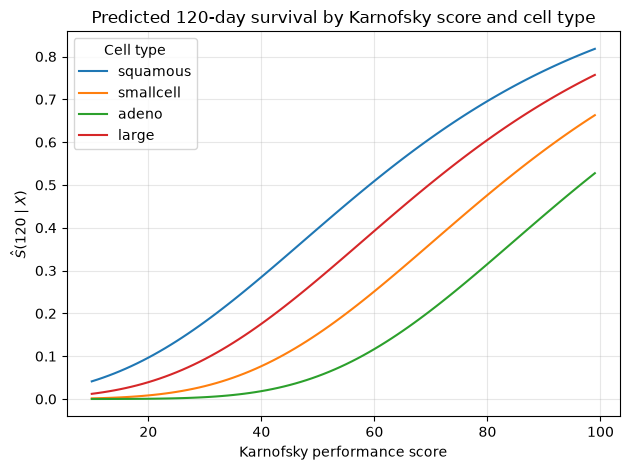

In [99]:
import matplotlib.pyplot as plt

# Karnofsky-score grid
karno_grid = np.arange(
    cox_df["karno"].min(),
    cox_df["karno"].max() + 1
)

cell_types = ["squamous", "smallcell", "adeno", "large"]

prediction_rows = []

for celltype in cell_types:
    for karno in karno_grid:
        prediction_rows.append({
            "karno": karno,
            "celltype": celltype
        })

plot_df = pd.DataFrame(prediction_rows)

# Use the same cell-type coding as in the fitted Cox model
plot_df["celltype"] = pd.Categorical(
    plot_df["celltype"],
    categories=cell_types
)

plot_X = pd.get_dummies(
    plot_df,
    columns=["celltype"],
    drop_first=True,
    dtype=float
)

# Ensure the columns exactly match those used by the reduced model
plot_X = plot_X.reindex(
    columns=X_reduced.columns,
    fill_value=0
)

# Predict survival probability at t = 120
survival_120 = reduced_cph.predict_survival_function(
    plot_X,
    times=[120]
)

plot_df["survival_120"] = survival_120.iloc[0].to_numpy()

# Plot one curve for each cell type
for celltype in cell_types:
    subset = plot_df[plot_df["celltype"] == celltype]

    plt.plot(
        subset["karno"],
        subset["survival_120"],
        label=celltype
    )

plt.xlabel("Karnofsky performance score")
plt.ylabel(r"$\hat{S}(120 \mid X)$")
plt.title("Predicted 120-day survival by Karnofsky score and cell type")
plt.legend(title="Cell type")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section c

In [100]:
# --------------------------------------------------
# Relative risk scores: psi(X) = beta_hat^T X
# --------------------------------------------------

psi_full = full_cph.predict_log_partial_hazard(X_full)
psi_reduced = reduced_cph.predict_log_partial_hazard(X_reduced)

# --------------------------------------------------
# Predicted cumulative risk: pi_t(X) = 1 - S_hat(t | X)
# --------------------------------------------------

risk_full = 1 - survival_full
risk_reduced = 1 - survival_reduced

print("Full-model relative risk scores:")
display(psi_full.head())

print("Reduced-model relative risk scores:")
display(psi_reduced.head())

print("Full-model cumulative risks:")
display(risk_full.head())

print("Reduced-model cumulative risks:")
display(risk_reduced.head())

Full-model relative risk scores:


0   -0.904028
1   -1.186374
2   -0.628042
3   -0.850611
4   -1.195277
dtype: float64

Reduced-model relative risk scores:


0   -0.587403
1   -0.897970
2   -0.587403
3   -0.587403
4   -0.897970
dtype: float64

Full-model cumulative risks:


,0,1,2,3,4,5,6,7,8,9,...,127,128,129,130,131,132,133,134,135,136
1.0,0.004136,0.003120,0.005447,0.004363,0.003093,0.018141,0.007937,0.002173,0.007218,0.002958,...,0.028798,0.008582,0.023323,0.009977,0.004553,0.005311,0.008735,0.006142,0.004512,0.029307
2.0,0.006231,0.004702,0.008204,0.006572,0.004660,0.027233,0.011946,0.003275,0.010865,0.004458,...,0.043112,0.012914,0.034965,0.015008,0.006858,0.008000,0.013144,0.009248,0.006798,0.043869
3.0,0.008356,0.006307,0.010997,0.008813,0.006251,0.036387,0.016004,0.004394,0.014559,0.005980,...,0.057444,0.017298,0.046655,0.020096,0.009196,0.010724,0.017606,0.012395,0.009115,0.058445
4.0,0.010527,0.007948,0.013850,0.011102,0.007878,0.045672,0.020142,0.005538,0.018327,0.007536,...,0.071897,0.021767,0.058479,0.025278,0.011584,0.013507,0.022153,0.015607,0.011482,0.073140
7.0,0.017100,0.012921,0.022474,0.018030,0.012807,0.073358,0.032619,0.009010,0.029696,0.012253,...,0.114499,0.035231,0.093540,0.040868,0.018810,0.021919,0.035852,0.025311,0.018645,0.116432


Reduced-model cumulative risks:


,0,1,2,3,4,5,6,7,8,9,...,127,128,129,130,131,132,133,134,135,136
1.0,0.005919,0.004342,0.005919,0.005919,0.004342,0.020352,0.010988,0.003185,0.008066,0.004342,...,0.020658,0.008188,0.020658,0.008188,0.004408,0.005147,0.008188,0.006009,0.004408,0.020658
2.0,0.008909,0.006538,0.008909,0.008909,0.006538,0.030518,0.016516,0.004797,0.012133,0.006538,...,0.030974,0.012317,0.030974,0.012317,0.006637,0.007748,0.012317,0.009043,0.006637,0.030974
3.0,0.011923,0.008754,0.011923,0.011923,0.008754,0.040693,0.022076,0.006425,0.016231,0.008754,...,0.041299,0.016475,0.041299,0.016475,0.008887,0.010372,0.016475,0.012103,0.008887,0.041299
4.0,0.015005,0.011021,0.015005,0.015005,0.011021,0.051015,0.027744,0.008091,0.020413,0.011021,...,0.051770,0.020720,0.051770,0.020720,0.011188,0.013055,0.020720,0.015231,0.011188,0.051770
7.0,0.024301,0.017872,0.024301,0.024301,0.017872,0.081677,0.044752,0.013132,0.033004,0.017872,...,0.082865,0.033497,0.082865,0.033497,0.018141,0.021156,0.033497,0.024666,0.018141,0.082865


# Question 4.2: Evaluation metrics

## Section a

In [101]:
from lifelines import KaplanMeierFitter

In [102]:
y = cox_df["time"].to_numpy(dtype=float)
delta = cox_df["status"].to_numpy(dtype=int)

In [103]:
percentiles = [20, 40, 60, 80]
horizons = np.percentile(y, percentiles)

for percentile, horizon in zip(percentiles, horizons):
    print(f"{percentile}th percentile: t = {horizon:.2f}")

20th percentile: t = 20.00
40th percentile: t = 51.00
60th percentile: t = 99.60
80th percentile: t = 174.40


In [104]:
def km_censoring_survival(y, delta):
    """
    KM estimator of G(t) = P(C >= t),
    treating censoring (1 - delta) as the event.
    """
    kmf = KaplanMeierFitter()
    kmf.fit(y, event_observed=1 - delta)

    def G_hat(t):
        t = np.atleast_1d(np.asarray(t, dtype=float))

        return np.array([
            max(
                kmf.survival_function_at_times([ti]).values[0],
                1e-6
            )
            for ti in t
        ])

    return G_hat


G_hat = km_censoring_survival(y, delta)

In [105]:
psi_full_array = psi_full.to_numpy().ravel()
psi_reduced_array = psi_reduced.to_numpy().ravel()

In [106]:
def harrell_c(y, delta, psi):
    """
    Harrell's C-index.
    A larger psi means higher predicted risk.
    """
    concordant = 0.0
    comparable = 0.0
    n = len(y)

    for i in range(n):
        # Patient i must have an observed event
        if delta[i] == 0:
            continue

        # Patients known to have survived longer than patient i
        mask = y > y[i]

        comparable += mask.sum()

        concordant += (
            (psi[i] > psi[mask]).sum()
            + 0.5 * (psi[i] == psi[mask]).sum()
        )

    return concordant / comparable if comparable > 0 else np.nan

In [107]:
harrell_full = harrell_c(
    y,
    delta,
    psi_full_array
)

harrell_reduced = harrell_c(
    y,
    delta,
    psi_reduced_array
)

print(f"Harrell C, full model:    {harrell_full:.4f}")
print(f"Harrell C, reduced model: {harrell_reduced:.4f}")

Harrell C, full model:    0.7384
Harrell C, reduced model: 0.7342


In [108]:
def uno_c(y, delta, psi, G_hat, tau):
    """
    Uno's IPCW C-index, restricted to event times up to tau.
    """
    g_yi = G_hat(y)

    weights = (
        delta
        * (y <= tau)
        / (g_yi ** 2)
    )

    concordant = 0.0
    denominator = 0.0
    n = len(y)

    for i in range(n):
        if weights[i] == 0:
            continue

        mask = y > y[i]

        denominator += weights[i] * mask.sum()

        concordant += weights[i] * (
            (psi[i] > psi[mask]).sum()
            + 0.5 * (psi[i] == psi[mask]).sum()
        )

    return concordant / denominator if denominator > 0 else np.nan

In [109]:
c_index_rows = []

for percentile, tau in zip(percentiles, horizons):

    uno_full = uno_c(
        y,
        delta,
        psi_full_array,
        G_hat,
        tau
    )

    uno_reduced = uno_c(
        y,
        delta,
        psi_reduced_array,
        G_hat,
        tau
    )

    c_index_rows.append({
        "Percentile": percentile,
        "Horizon": tau,
        "Harrell C, full": harrell_full,
        "Harrell C, reduced": harrell_reduced,
        "Uno C, full": uno_full,
        "Uno C, reduced": uno_reduced
    })

c_index_results = pd.DataFrame(c_index_rows)
c_index_results

,Percentile,Horizon,"Harrell C, full","Harrell C, reduced","Uno C, full","Uno C, reduced"
0,20,20.0,0.738434,0.734171,0.788008,0.777920
1,40,51.0,0.738434,0.734171,0.780442,0.771934
2,60,99.6,0.738434,0.734171,0.775990,0.766167
3,80,174.4,0.738434,0.734171,0.738492,0.733985


## Section b

In [110]:
def calibration_plot(y, delta, pi_hat, t_star, K=10, ax=None):
    """
    KM-based grouped calibration plot at time t_star.
    """
    if ax is None:
        fig, ax = plt.subplots()

    order = np.argsort(pi_hat)
    bins = np.array_split(order, K)

    mean_pred, km_est = [], []
    
    for idx in bins:
        mean_pred.append(pi_hat[idx].mean())
        kmf = KaplanMeierFitter()
        kmf.fit(y[idx], event_observed=delta[idx])

        observed_survival = (
            kmf
            .survival_function_at_times([t_star])
            .values[0]
        )

        km_est.append(1.0 - float(observed_survival))

    ax.scatter(
        mean_pred,
        km_est,
        s=60,
        zorder=3,
        label="Decile groups"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=1,
        label="Perfect calibration"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted cumulative risk")
    ax.set_ylabel(f"Estimated P(T ≤ {t_star:.1f})")
    ax.legend()

    return ax

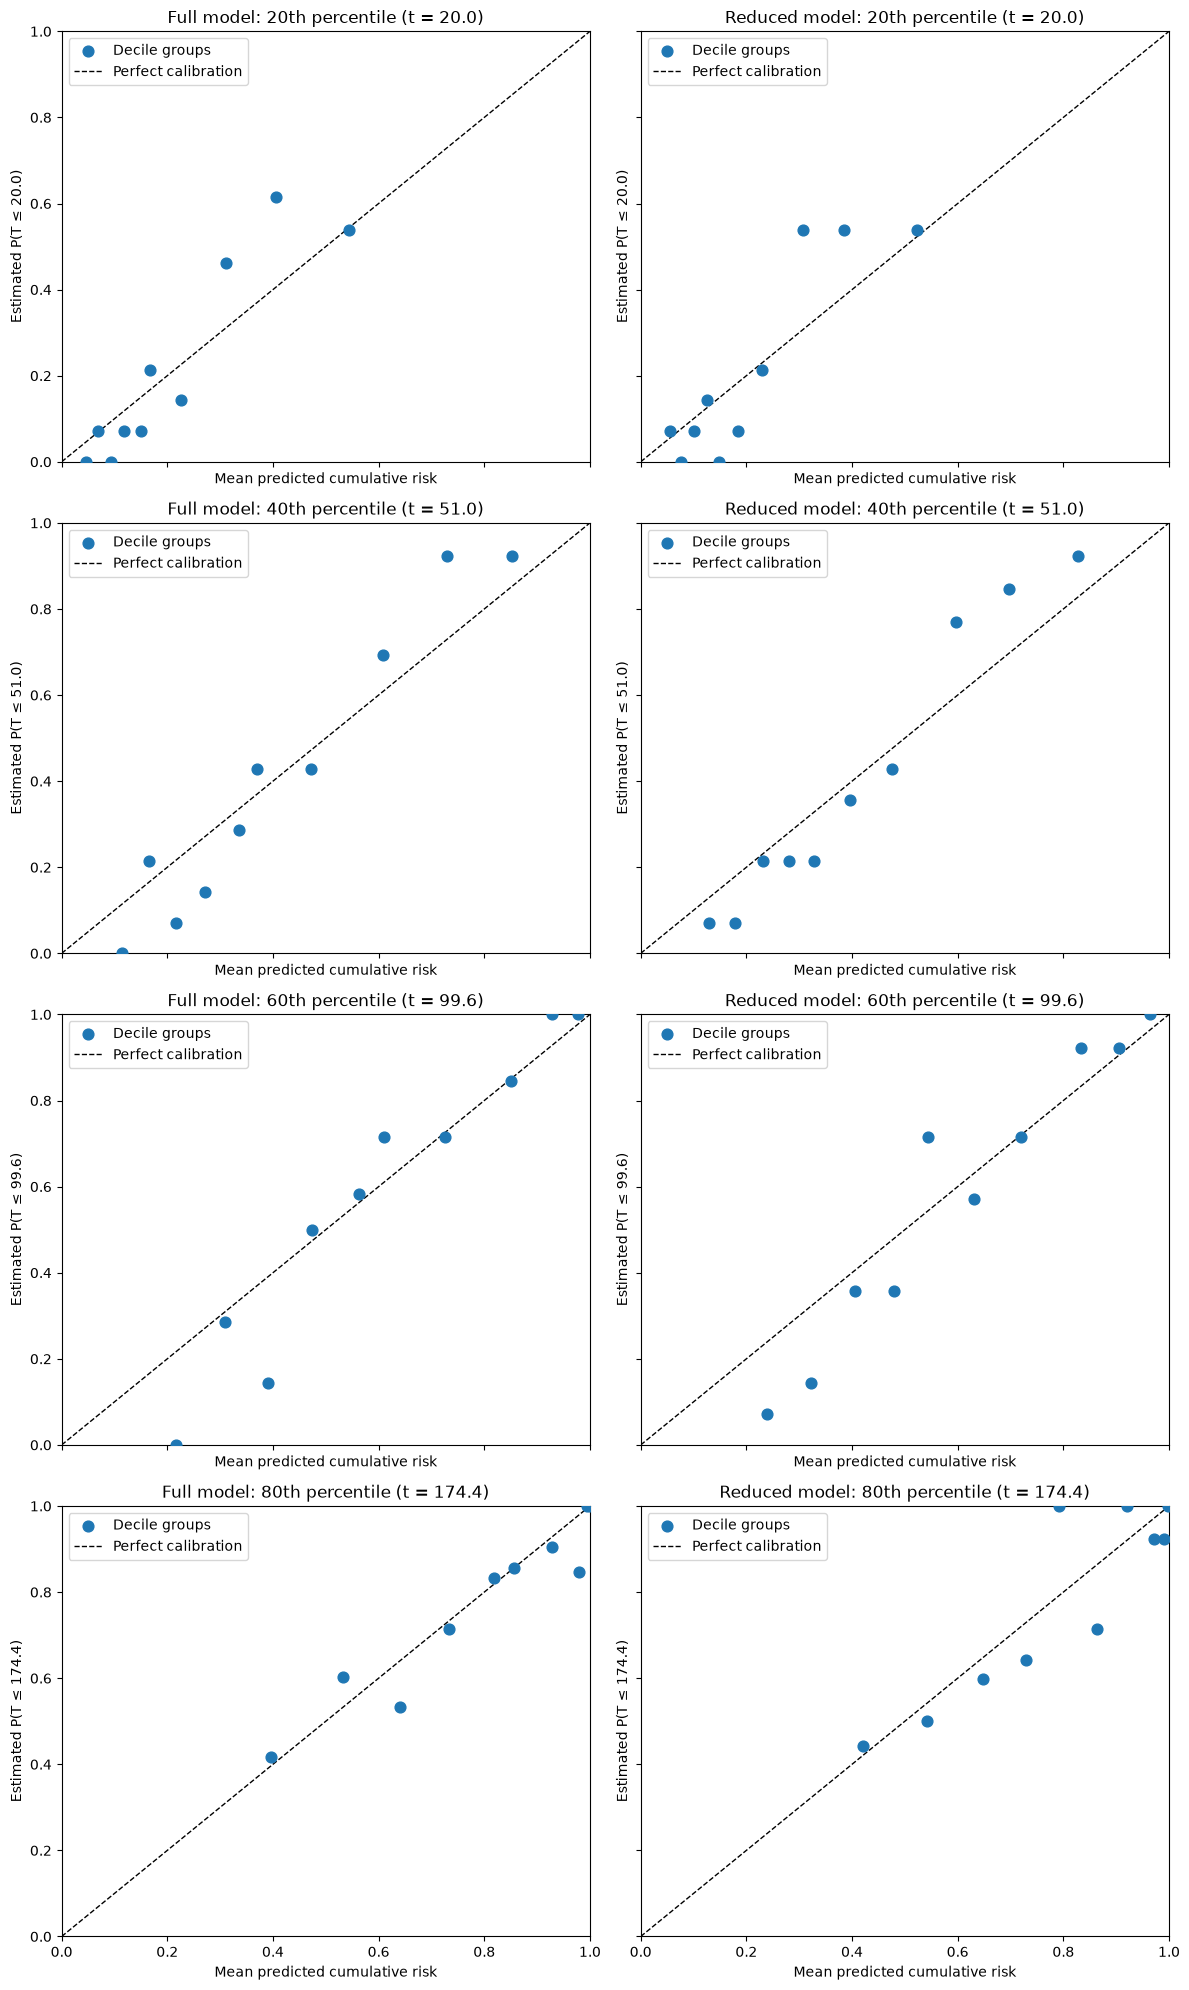

In [111]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(12, 20),
    sharex=True,
    sharey=True
)

for row, (percentile, horizon) in enumerate(
    zip(percentiles, horizons)
):
    # Predicted cumulative risks from the full model
    pi_full = (
        1
        - full_cph
        .predict_survival_function(
            X_full,
            times=[horizon]
        )
        .T
        .values
        .ravel()
    )

    # Predicted cumulative risks from the reduced model
    pi_reduced = (
        1
        - reduced_cph
        .predict_survival_function(
            X_reduced,
            times=[horizon]
        )
        .T
        .values
        .ravel()
    )

    calibration_plot(
        y,
        delta,
        pi_full,
        t_star=horizon,
        K=10,
        ax=axes[row, 0]
    )

    axes[row, 0].set_title(
        f"Full model: {percentile}th percentile "
        f"(t = {horizon:.1f})"
    )

    calibration_plot(
        y,
        delta,
        pi_reduced,
        t_star=horizon,
        K=10,
        ax=axes[row, 1]
    )

    axes[row, 1].set_title(
        f"Reduced model: {percentile}th percentile "
        f"(t = {horizon:.1f})"
    )

plt.tight_layout()
plt.show()

## Section c

In [112]:
def ipcw_brier(y, delta, pi_t, t, G_hat):
    """
    IPCW Brier score at time t.
    """
    n = len(y)
    g_yi = G_hat(y)
    g_t = G_hat(np.array([t]))[0]

    event_before = (y <= t) & (delta == 1)
    survive_past = y > t

    weights = np.zeros(n)
    weights[event_before] = ( 1.0 / g_yi[event_before])
    weights[survive_past] = (
        1.0 / g_t
    )

    y_obs = (y <= t).astype(float)

    return np.mean(
        weights * (y_obs - pi_t) ** 2
    )

In [113]:
def ipcw_log_loss(
    y,
    delta,
    pi_t,
    t,
    G_hat,
    eps=1e-12
):
    """
    IPCW binary log-loss at time t.
    """
    n = len(y)

    g_yi = G_hat(y)
    g_t = G_hat(np.array([t]))[0]

    event_before = (y <= t) & (delta == 1)
    survive_past = y > t

    weights = np.zeros(n)

    weights[event_before] = (
        1.0 / g_yi[event_before]
    )

    weights[survive_past] = (
        1.0 / g_t
    )

    y_obs = (y <= t).astype(float)

    # Avoid taking log(0)
    pi_t = np.clip(pi_t, eps, 1.0 - eps)

    individual_loss = -(
        y_obs * np.log(pi_t)
        + (1.0 - y_obs) * np.log(1.0 - pi_t)
    )

    return np.mean(weights * individual_loss)

In [114]:
prediction_error_rows = []

for percentile, horizon in zip(percentiles, horizons):

    pi_full = (
        1
        - full_cph
        .predict_survival_function(
            X_full,
            times=[horizon]
        )
        .T
        .values
        .ravel()
    )

    pi_reduced = (
        1
        - reduced_cph
        .predict_survival_function(
            X_reduced,
            times=[horizon]
        )
        .T
        .values
        .ravel()
    )

    prediction_error_rows.append({
        "Percentile": percentile,
        "Horizon": horizon,

        "Brier, full": ipcw_brier(
            y, delta, pi_full, horizon, G_hat
        ),

        "Brier, reduced": ipcw_brier(
            y, delta, pi_reduced, horizon, G_hat
        ),

        "Log-loss, full": ipcw_log_loss(
            y, delta, pi_full, horizon, G_hat
        ),

        "Log-loss, reduced": ipcw_log_loss(
            y, delta, pi_reduced, horizon, G_hat
        )
    })

prediction_error_results = pd.DataFrame(
    prediction_error_rows
)

prediction_error_results

,Percentile,Horizon,"Brier, full","Brier, reduced","Log-loss, full","Log-loss, reduced"
0,20,20.0,0.130306,0.131769,0.408509,0.413363
1,40,51.0,0.154381,0.159064,0.479245,0.490959
2,60,99.6,0.151463,0.157294,0.458684,0.476281
3,80,174.4,0.143037,0.137965,0.427590,0.422925


## Section d

They are optimistic because the models were evaluated on the same data used to fit them, so performance benefits from overfitting. A less biased estimate could be obtained using a separate test set or cross-validation, with the model fitted only on the training folds and evaluated on held-out patients.

## Section e

The full model shows slightly better discrimination than the reduced model. Its Harrell’s C-index is 0.738 versus 0.734, and its Uno’s C-index is also consistently a little higher at all four horizons.

The calibration plots are broadly similar, with no clear and consistent advantage for either model.

Prediction error is also very close: the full model performs slightly better at the 20th, 40th, and 60th percentile horizons, while the reduced model is slightly better at the 80th percentile horizon. Overall, adding age and trt provides only a very small improvement in discrimination and little clear improvement in calibration or prediction error. The reduced model therefore appears nearly as predictive.